# PCA

In [40]:
#functions
import numpy as np
import pandas as pd
import umap
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import math
from scipy.special import factorial
import tqdm

def plot(transformed_data, title, x_label, y_label):
    plt.figure(figsize=(8, 6))
    plt.scatter(transformed_data[:, 0], transformed_data[:, 1], s=5)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()

dataset=pd.read_csv('pca_data.txt', sep=' ', header=None)
dataset=dataset.to_numpy()
dataset=StandardScaler().fit_transform(dataset)
np.random.seed(42)
top=2

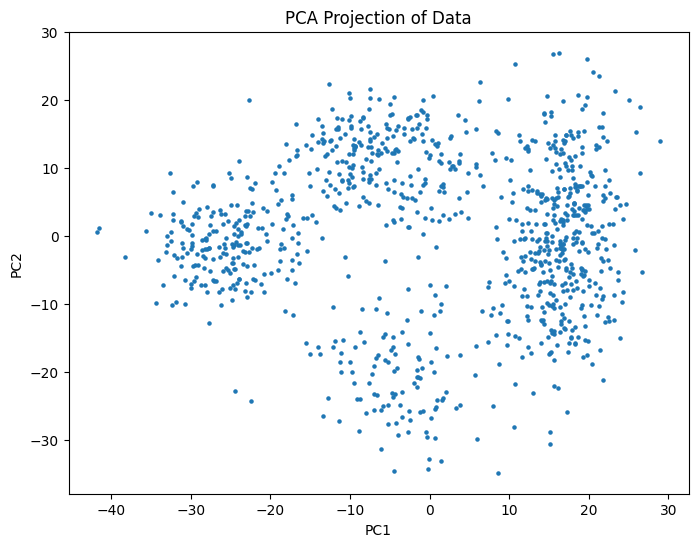

In [41]:
#pca
centered_data=dataset-np.mean(dataset,axis=0)
covariance_matrix=np.dot(centered_data.T,centered_data)/(centered_data.shape[0])
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

sorted_index = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:, sorted_index]

top_eigenvectors = sorted_eigenvectors[:, :top]
transformed_data = np.dot(dataset, top_eigenvectors)
plot(transformed_data, 'PCA Projection of Data', 'PC1', 'PC2')


# UMAP & t-SNE

c:\Users\Binary Gadget\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


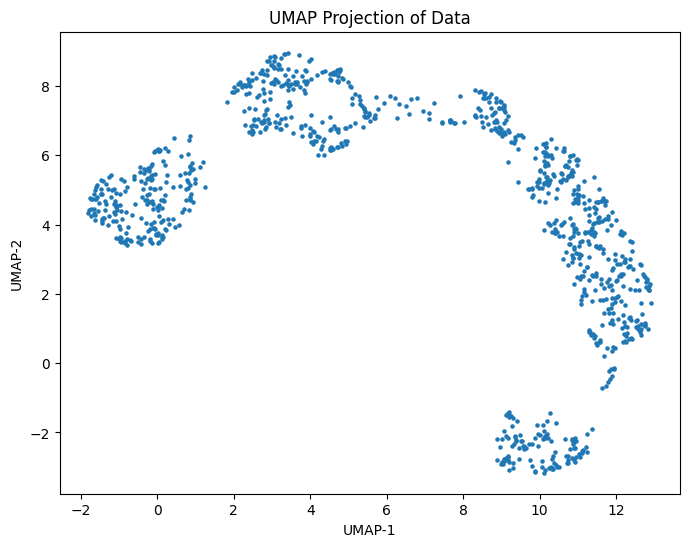

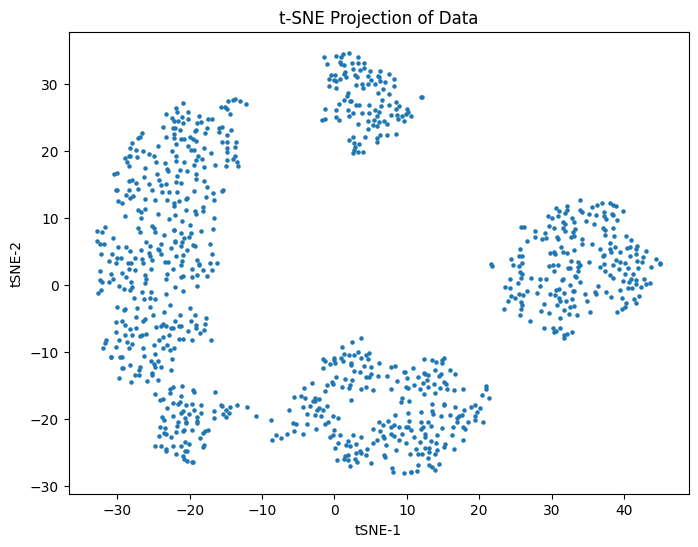

In [42]:
#umap
ump = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
transformed_data = ump.fit_transform(dataset)

plot(transformed_data, "UMAP Projection of Data", "UMAP-1", "UMAP-2")

#tsne
tsne = TSNE(n_components=2, random_state=42)
transformed_data = tsne.fit_transform(dataset)

plot(transformed_data, "t-SNE Projection of Data", "tSNE-1", "tSNE-2")


# EM

In [43]:
dataset=pd.read_csv('em_data.txt', header=None)
dataset=dataset.to_numpy()
lamda=[2,8]
pi=[0.5,0.5]
lamda=np.array(lamda)
pi=np.array(pi)

def poison(lamda, x):
    exp=np.exp(-lamda)
    result=lamda**x
    # print(result.shape)
    result=result*exp
    # print(result.shape)
    factorials=factorial(x, exact=True)
    # print("factorials",factorials.shape)
    result=result/factorials
    # print("Result",result.shape)
    return result

def e_step(dataset, lamda, pi):
    n=dataset.shape[0]
    k=lamda.shape[0]
    r=poison(lamda, dataset)*pi
    # print(r.shape)
    alpha=np.sum(r,axis=1, keepdims=True)
    # print("alpha",alpha.shape)
    r=r/alpha
    return r

def m_step(dataset, r):
    n=dataset.shape[0]
    s=np.sum(r,axis=0,keepdims=True)
    pi=s/n
    lamda=np.dot(r.T, dataset).T/s
    # print("pi",pi,"lamda",lamda)
    return lamda, pi

def em(dataset, lamda, pi, max_iter=1000):
    prev_r=None
    for i in range(max_iter):
        r=e_step(dataset, lamda, pi)
        lamda, pi=m_step(dataset, r)
        
        if prev_r is not None and np.allclose(prev_r, r):
            print("Converged at iteration: ", i)
            break
        prev_r=r
    return lamda, pi


lamda, pi=em(dataset,lamda,pi)
lamda=np.round(lamda,8)
pi=np.round(pi,8)

print("Mean number of children (families with family planning): ",lamda[0][0])
print("Mean number of children (families without family planning):",lamda[0][1])
print("Proportion of families with family planning: ",pi[0][0])
print("Proportion of families without family planning:",pi[0][1])


Converged at iteration:  179
Mean number of children (families with family planning):  1.78242202
Mean number of children (families without family planning): 4.91073091
Proportion of families with family planning:  0.35601692
Proportion of families without family planning: 0.64398308
